<center> <h1> All Hypothesis testing techniques codes on Disney Hotstar Movies dataset </h1> </center>

In [1]:
#Import required libraries:
import pandas as pd
import numpy as np

#Ignore all incoming warnings (if any):
import warnings
warnings.filterwarnings("ignore")

#Import the dataset: 
df = pd.read_csv("dataset.csv")



In [2]:
#Preview of the dataset:
print(df.info())

print("\n\n\n")


print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          469 non-null    object
 1   Released year  473 non-null    int64 
 2   Duration       473 non-null    object
 3   Genre          473 non-null    object
 4   Language       473 non-null    object
 5   Description    473 non-null    object
dtypes: int64(1), object(5)
memory usage: 22.3+ KB
None




Title            4
Released year    0
Duration         0
Genre            0
Language         0
Description      0
dtype: int64


In [3]:
df.shape

(473, 6)

In [4]:
#Drop rows with null values:
df = df.dropna()

In [5]:
df.shape

(469, 6)

In [6]:
df.isnull().sum()

Title            0
Released year    0
Duration         0
Genre            0
Language         0
Description      0
dtype: int64

In [7]:
df.columns

Index(['Title', 'Released year', 'Duration', 'Genre', 'Language',
       'Description'],
      dtype='object')

In [8]:
#Rename columns:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [9]:
df.columns

Index(['title', 'released_year', 'duration', 'genre', 'language',
       'description'],
      dtype='object')

In [10]:
#Check for any duplicates:
df.duplicated().sum()

np.int64(0)

In [11]:
#Inspect the Duration column:
df["duration"].values

array(['2h 48m', '2h 11m', '2h 33m', '2h 36m', '2h 22m', '2h 18m',
       '2h 26m', '2h 9m', '2h 14m', '2h 51m', '1h 59m', '2h 8m', '1h 57m',
       '2h 15m', '2h 24m', '1h 36m', '2h 23m', '2h 14m', '2h 16m',
       '2h 21m', '2h 31m', '1h 56m', '2h 8m', '2h 10m', '2h 33m',
       '2h 12m', '2h 8m', '1h 53m', '1h 55m', '2h 49m', '2h 8m', '2h 58m',
       '1h 26m', '2h 7m', '1h 44m', '2h 15m', '2h 1m', '2h 33m', '2h 13m',
       '2h 31m', '2h 10m', '2h 2m', '1h 54m', '2h 11m', '2h 16m',
       '2h 33m', '2h 11m', '1h 53m', '2h 3m', '2h 32m', '2h 13m', '2h 3m',
       '2h 14m', '1h 49m', '2h 15m', '2h 22m', '2h 14m', '2h 13m',
       '2h 42m', '1h 58m', '2h 28m', '2h 25m', '2h 3m', '2h 3m', '2h 29m',
       '2h 25m', '1h 28m', '2h 35m', '2h 8m', '40m', '2h 7m', '1h 22m',
       '1h 22m', '2h 18m', '2h 40m', '2h 3m', '2h 13m', '2h 14m',
       '2h 10m', '2h 25m', '1h 57m', '2h 32m', '1h 39m', '2h 26m',
       '1h 54m', '1h 40m', '1h 56m', '2h 9m', '2h 40m', '1h 46m',
       '2h 28m', '2h'

In [12]:
#Now convert the durations into minutes from hrs minutes format:
def convert_duration(x):
    try:
        h = int(x.split('h')[0])
        m = int(x.split('h')[1].replace('m', '').strip())
        return h*60 + m
    except:
        return np.nan

df['duration_min'] = df['duration'].apply(convert_duration)

In [13]:
df["duration_min"].values

array([168., 131., 153., 156., 142., 138., 146., 129., 134., 171., 119.,
       128., 117., 135., 144.,  96., 143., 134., 136., 141., 151., 116.,
       128., 130., 153., 132., 128., 113., 115., 169., 128., 178.,  86.,
       127., 104., 135., 121., 153., 133., 151., 130., 122., 114., 131.,
       136., 153., 131., 113., 123., 152., 133., 123., 134., 109., 135.,
       142., 134., 133., 162., 118., 148., 145., 123., 123., 149., 145.,
        88., 155., 128.,  nan, 127.,  82.,  82., 138., 160., 123., 133.,
       134., 130., 145., 117., 152.,  99., 146., 114., 100., 116., 129.,
       160., 106., 148.,  nan, 133., 140., 136., 156., 132., 143., 113.,
        89., 177., 116., 111., 125., 131., 177., 130., 178., 110., 143.,
       137., 138., 125., 145., 116., 148., 122., 149., 150., 140.,  99.,
       137., 136., 136., 128.,  90., 102., 113., 162., 126., 155., 143.,
       139., 117., 122., 127., 143., 164., 148., 116., 122., 135., 126.,
       141., 123., 115., 129., 150., 117., 103., 16

In [14]:
#Check all genres:
df["genre"].value_counts()

genre
Action             150
Comedy              85
Drama               67
Thriller            50
Romance             49
Horror              21
Crime               13
Family               8
Biopic               7
Kids                 6
Animation            3
Mystery              3
Adventure            2
Fantasy              1
Documentary          1
Historical           1
Sports               1
Science Fiction      1
Name: count, dtype: int64

In [15]:
df.language.value_counts()

language
Action             142
Comedy              82
Drama               66
Thriller            48
Romance             47
Horror              21
Hindi               18
Crime               13
Family               8
Biopic               6
Kids                 6
Mystery              3
Animation            3
Adventure            2
Tamil                1
Historical           1
Sports               1
Science Fiction      1
Name: count, dtype: int64

In [16]:
#The language column contains invalid values in majority. hence we will drop this column:
df.drop(columns="language",inplace=True)

In [17]:
df.columns

Index(['title', 'released_year', 'duration', 'genre', 'description',
       'duration_min'],
      dtype='object')

## Feature Engineering:

In [18]:

current_year = 2026
df["content_age"] = current_year - df["released_year"]

# title length
df["title_length"] = df["title"].apply(len)


# description length
df["description_length"] = df["description"].apply(len)

df["description_word_count"] = df["description"].apply(
    lambda x: len(str(x).split())
)


# long description feature
df["is_long_desc"] = df["description_word_count"].apply(
    lambda x: 1 if x >= 25 else 0
)



# duration category
def duration_category(minutes):
    if minutes < 120:
        return "Short"
    elif minutes <= 150:
        return "Medium"
    else:
        return "Long"

df["duration_category"] = df["duration_min"].apply(duration_category)




# content age category
def age_category(age):
    if age <= 5:
        return "Recent"
    elif age <= 10:
        return "Moderate"
    else:
        return "Old"

df["content_age_category"] = df["content_age"].apply(age_category)

## Hypothesis testing questions:

### Q1] Is the average movie duration significantly greater than 120 minutes? (Z - Test)

<Axes: xlabel='duration', ylabel='Count'>

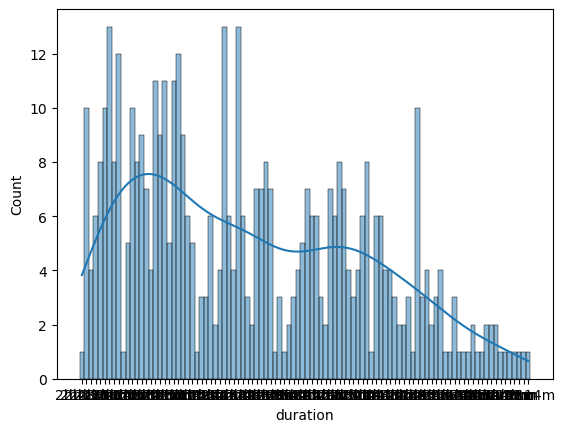

In [19]:
import seaborn as sns
sns.histplot(x="duration",data=df,kde=True)

In [20]:
from scipy.stats import norm

# sample data
data = df["duration_min"]

# parameters
sample_mean = np.mean(data)
sigma = np.std(data, ddof=1)   # using sample std as approximation
n = len(data)

mu = 120   # hypothesized population mean

# compute Z-score
z = (sample_mean - mu) / (sigma / np.sqrt(n))

# p-value (right-tailed test)
p_value = 1 - norm.cdf(z)

print("Sample Mean:", sample_mean)
print("Z-score:", z)
print("P-value:", p_value)



alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Average duration is significantly greater than 120 minutes")
else:
    print("Fail to Reject H0 → No strong evidence that duration > 120 minutes")

Sample Mean: 129.9232456140351
Z-score: 10.595418018362723
P-value: 0.0
Reject H0 → Average duration is significantly greater than 120 minutes


### Q2] Is the average content age of movies significantly less than 10 years? (Z TEST)

In [21]:
from scipy.stats import norm

# sample data
data = df["content_age"]

# parameters
sample_mean = np.mean(data)
sigma = np.std(data, ddof=1)   # using sample std as approximation
n = len(data)

mu = 10   # hypothesized population mean

# compute Z-score
z = (sample_mean - mu) / (sigma / np.sqrt(n))

# p-value (left-tailed test)
p_value = norm.cdf(z)

print("Sample Mean:", sample_mean)
print("Z-score:", z)
print("P-value:", p_value)



alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Average content age of movies  is significantly less than 10 years")
else:
    print("Fail to Reject H0 → Average content age of movies  is not less than 10 years")

Sample Mean: 12.315565031982942
Z-score: 6.204537342603721
P-value: 0.9999999997257097
Fail to Reject H0 → Average content age of movies  is not less than 10 years


### Q3] Is the average movie duration different from 120 minutes? (Z TEST)

In [22]:
from scipy.stats import norm

# sample data
data = df["duration_min"]

# parameters
sample_mean = np.mean(data)
sigma = np.std(data, ddof=1)   # using sample std as approximation
n = len(data)

mu = 10   # hypothesized population mean

# compute Z-score
z = (sample_mean - mu) / (sigma / np.sqrt(n))

# p-value (two-tailed test)
p_value = 2 * (1 - norm.cdf(abs(z)))

print("Sample Mean:", sample_mean)
print("Z-score:", z)
print("P-value:", p_value)



alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Average movie duration is significantly different from 120 minutes.")
else:
    print("Fail to Reject H0 → Average movie duration is not different from 120 minutes.")

Sample Mean: 129.9232456140351
Z-score: 128.04650482522985
P-value: 0.0
Reject H0 → Average movie duration is significantly different from 120 minutes.


### Q4] Do long movies (duration > 150 minutes) have a higher average description word count compared to other movies? (T-TEST)

In [23]:
from scipy.stats import ttest_ind

# create groups
long_movies = df[df["duration_min"] > 150]["description_word_count"]
other_movies = df[df["duration_min"] <= 150]["description_word_count"]

# perform t-test (Welch's t-test)
t_stat, p_value_two_tailed = ttest_ind(long_movies, other_movies, equal_var=False)

# convert to right-tailed p-value
if t_stat > 0:
    p_value = p_value_two_tailed / 2
else:
    p_value = 1 - (p_value_two_tailed / 2)

alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Long movies have higher description word count")
else:
    print("Fail to Reject H0 → No significant evidence")

Fail to Reject H0 → No significant evidence


### Q5] Does the average movie duration differ across different genres? (ANOVA)

In [24]:
from scipy.stats import f_oneway


grouped_data = df.groupby("genre")["duration_min"]

groups = [group.values for name, group in grouped_data]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)


alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Average duration differs across genres")
else:
    print("Fail to Reject H0 → No significant difference")

F-statistic: nan
P-value: nan
Fail to Reject H0 → No significant difference


### Q6] Is movie genre related to duration category? (Chi-Square)

In [25]:
import pandas as pd
from scipy.stats import chi2_contingency

# create contingency table
contingency_table = pd.crosstab(df["genre"], df["duration_category"])

print("Contingency Table:\n", contingency_table)


# perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)


alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Genre and duration category are related")
else:
    print("Fail to Reject H0 → No significant relationship")

Contingency Table:
 duration_category  Long  Medium  Short
genre                                 
Action               30      82     38
Adventure             0       1      1
Animation             1       0      2
Biopic                4       2      1
Comedy                7      60     18
Crime                 3       3      7
Documentary           0       0      1
Drama                12      32     23
Family                1       7      0
Fantasy               1       0      0
Historical            1       0      0
Horror                0       9     12
Kids                  0       0      6
Mystery               0       3      0
Romance              11      31      7
Science Fiction       0       0      1
Sports                0       1      0
Thriller              7      23     20
Chi-square statistic: 85.28511055882859
P-value: 2.7100983279293523e-06
Degrees of freedom: 34
Reject H0 → Genre and duration category are related
